In [41]:
from datetime import timedelta

import pandas as pd

df_pred = pd.read_csv('/home/patrick/time-series-analysis/experiments/exp_2025-06-27/pred_ref/pred_72.csv',
                      index_col=0, parse_dates=True)
df_ref = pd.read_csv('/home/patrick/time-series-analysis/experiments/exp_2025-06-27/pred_ref/ref_72.csv'
                     , index_col=0, parse_dates=True)

df_pred.drop(columns=['extra'], inplace=True)

In [42]:
df_pred

,1,2,3,4,5,6,7,8
dt,,,,,,,,
2022-06-26 00:00:00+00:00,0.754063,0.742603,0.745583,0.757743,0.763312,0.758821,0.755692,0.761277
2022-08-21 00:00:00+00:00,0.658636,0.660913,0.633571,0.594101,0.565466,0.552190,0.543082,0.533292
2022-10-16 00:00:00+00:00,0.459502,0.488384,0.523960,0.547471,0.557541,0.572383,0.605216,0.642890
2022-12-11 00:00:00+00:00,0.618510,0.614973,0.598980,0.605093,0.644221,0.690998,0.715019,0.718634
2023-02-05 00:00:00+00:00,0.748469,0.778861,0.833351,0.871504,0.859653,0.804178,0.740808,0.697980
2023-04-02 00:00:00+00:00,0.688914,0.682313,0.683341,0.694729,0.705659,0.695014,0.656100,0.612156
2023-05-28 00:00:00+00:00,0.669863,0.673373,0.703182,0.722228,0.709511,0.678912,0.658983,0.660639
2023-07-23 00:00:00+00:00,0.733868,0.731944,0.725674,0.722330,0.721410,0.712531,0.689327,0.659440
2023-09-17 00:00:00+00:00,0.610275,0.609625,0.603376,0.592329,0.590874,0.610957,0.645706,0.674492


array([Timestamp('2022-06-26 00:00:00+0000', tz='UTC'),
       np.float64(0.7540628903085571), np.float64(0.742603080134484),
       np.float64(0.745583349547624), np.float64(0.7577434069455844),
       np.float64(0.7633123010218101), np.float64(0.7588206276050993),
       np.float64(0.755692319310598), np.float64(0.7612767883847682)],
      dtype=object)

[Timestamp('2022-06-26 00:00:00+0000', tz='UTC'),
 Timestamp('2022-07-03 00:00:00+0000', tz='UTC'),
 Timestamp('2022-07-10 00:00:00+0000', tz='UTC'),
 Timestamp('2022-07-17 00:00:00+0000', tz='UTC'),
 Timestamp('2022-07-24 00:00:00+0000', tz='UTC'),
 Timestamp('2022-07-31 00:00:00+0000', tz='UTC'),
 Timestamp('2022-08-07 00:00:00+0000', tz='UTC'),
 Timestamp('2022-08-14 00:00:00+0000', tz='UTC')]

2022-06-26 00:00:00+00:00    0.754063
2022-07-03 00:00:00+00:00    0.742603
2022-07-10 00:00:00+00:00    0.745583
2022-07-17 00:00:00+00:00    0.757743
2022-07-24 00:00:00+00:00    0.763312
2022-07-31 00:00:00+00:00    0.758821
2022-08-07 00:00:00+00:00    0.755692
2022-08-14 00:00:00+00:00    0.761277
Name: val, dtype: object

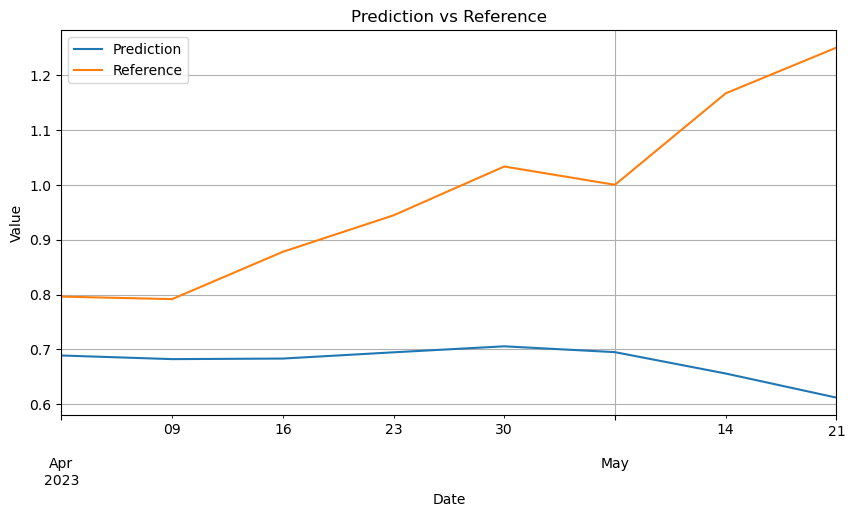

In [63]:
def traspose_series_from_df_row(df_pred, row):
    aux_df = df_pred.reset_index()
    transposed_values = aux_df.iloc[row,:].values
    #transposed_values.extend(aux_df.iloc[:,1].values)
    dates = [transposed_values[0] + timedelta(weeks=i) for i in range(len(transposed_values) -1)]
    transposed_series = pd.Series(transposed_values[1:], index=dates, name='val')
    return transposed_series

traspose_series_pred = traspose_series_from_df_row(df_pred, 5)
traspose_series_ref = traspose_series_from_df_row(df_ref, 5)

#plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
traspose_series_pred.plot(label='Prediction')
traspose_series_ref.plot(label='Reference')
plt.title('Prediction vs Reference')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()
